# Autoencoder + PCA preprocessing for Quantum ML

This notebook loads the `classical_qi_predictions_all_splits` dataset, applies PCA and an autoencoder to reduce dimensionality, and saves the transformed embeddings for downstream Quantum ML experiments.

## Dataset

The notebook expects the dataset at `outputs/classical_qi_predictions_all_splits.csv` relative to this notebook's folder.

In [1]:
# Imports and environment checks
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score
import torch
from torch import nn

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('sklearn available')
print('torch', torch.__version__)


pandas 3.0.2
numpy 1.26.4
sklearn available
torch 2.2.2


In [2]:
# Paths and loading
data_path = Path('/Users/stefan/Python_Projekte/4BE/QCentroid - ETH Hackathon 2026/aggregated_source_data.csv')
assert data_path.exists(), f'Data not found: {data_path}'
df = pd.read_csv(data_path)
print(f'Loaded {data_path}: {df.shape}')
display(df.head())
print(f"Malicious samples: {(df['is_malicious_source']==1).sum()}")
print(f"Benign samples:    {(df['is_malicious_source']==0).sum()}")


Loaded /Users/stefan/Python_Projekte/4BE/QCentroid - ETH Hackathon 2026/aggregated_source_data.csv: (2588, 34)


,family,split,scenario,dataset_name,src_ip,flow_count,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,...,dst_port_concentration,top_dst_ip,top_protocol,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share,is_malicious_source
0,family_a,test,attack,attack_test_01,59.166.0.7,9360,10,2934,2,2822.727850,...,0.211325,149.171.126.0,TCP,0.772650,0.227350,0.0,0.618483,0.064530,0.052350,0
1,family_a,test,attack,attack_test_01,59.166.0.8,9390,10,2878,2,2807.146043,...,0.220980,149.171.126.1,TCP,0.781470,0.218530,0.0,0.618637,0.063685,0.051757,0
2,family_a,test,attack,attack_test_01,59.166.0.0,9797,10,2919,2,2793.548094,...,0.217618,149.171.126.0,TCP,0.770644,0.229356,0.0,0.621823,0.060937,0.054098,0
3,family_a,test,attack,attack_test_01,59.166.0.4,9782,10,3046,2,2857.151556,...,0.208444,149.171.126.4,TCP,0.773359,0.226641,0.0,0.615007,0.064200,0.054386,0
4,family_a,test,attack,attack_test_01,59.166.0.1,9982,10,2962,2,2734.413435,...,0.219495,149.171.126.0,TCP,0.778000,0.222000,0.0,0.621419,0.059507,0.054498,0


Malicious samples: 955
Benign samples:    1633


In [3]:
# Drop audit/id Spalten
df_cleared = df.drop(columns=['src_ip', 'family', 'scenario', 'split', 'dataset_name', 'flow_count'], errors='ignore')

# Labels separat halten
labels = df_cleared['is_malicious_source'].values
df_features = df_cleared.drop(columns=['is_malicious_source'], errors='ignore')

# Nur numerische Spalten
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
X_all = df_features[numeric_cols].fillna(df_features[numeric_cols].mean()).values
feature_names = numeric_cols

print(f'Feature matrix: {X_all.shape}')
print(f'Features: {feature_names}')

# Benign/Malicious trennen
mask_benign    = labels == 0
mask_malicious = labels == 1
X_benign    = X_all[mask_benign]
X_malicious = X_all[mask_malicious]

# Train/Val Split NUR auf Benign
X_train, X_val = train_test_split(X_benign, test_size=0.2, random_state=42)
print(f'Train (benign):    {X_train.shape}')
print(f'Val   (benign):    {X_val.shape}')
print(f'Test  (malicious): {X_malicious.shape}')


Feature matrix: (2588, 25)
Features: ['unique_dst_ip', 'unique_dst_port', 'unique_protocols', 'pps_mean', 'pps_max', 'bps_mean', 'bps_max', 'duration_mean', 'duration_max', 'packet_size_avg_mean', 'packet_size_avg_std', 'outbound_ratio_mean', 'outbound_ratio_min', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'total_packets_sum', 'total_bytes_sum', 'dst_concentration', 'dst_port_concentration', 'tcp_share', 'udp_share', 'icmp_share', 'small_packet_share', 'high_pps_share', 'low_outbound_share']
Train (benign):    (1306, 25)
Val   (benign):    (327, 25)
Test  (malicious): (955, 25)


In [4]:
# Feature matrix already prepared above
# X_train, X_val, X_malicious are ready
print('shape (train):', X_train.shape)
print(f'Features: {feature_names}')


shape (train): (1306, 25)
Features: ['unique_dst_ip', 'unique_dst_port', 'unique_protocols', 'pps_mean', 'pps_max', 'bps_mean', 'bps_max', 'duration_mean', 'duration_max', 'packet_size_avg_mean', 'packet_size_avg_std', 'outbound_ratio_mean', 'outbound_ratio_min', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'total_packets_sum', 'total_bytes_sum', 'dst_concentration', 'dst_port_concentration', 'tcp_share', 'udp_share', 'icmp_share', 'small_packet_share', 'high_pps_share', 'low_outbound_share']


In [5]:
# Autoencoder followed by PCA
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super().__init__()
        # Encoder: monoton sinkend, BatchNorm
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, encoding_dim),
        )
        # Decoder: Spiegel des Encoders
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Normalisierung auf [0, 1] — fit NUR auf Train
scaler_01 = MinMaxScaler()
X_train_scaled    = scaler_01.fit_transform(X_train)
X_val_scaled      = scaler_01.transform(X_val)
X_malicious_scaled = scaler_01.transform(X_malicious)

from torch.utils.data import DataLoader, TensorDataset
train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

input_dim    = X_train.shape[1]
encoding_dim = 20  # Latent space des klassischen AE

autoencoder = Autoencoder(input_dim, encoding_dim)
criterion   = nn.MSELoss()
optimizer   = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

print(f'Input dim:    {input_dim}')
print(f'Encoding dim: {encoding_dim}')
print(f'AE Parameters: {sum(p.numel() for p in autoencoder.parameters()):,}')


Input dim:    25
Encoding dim: 20
AE Parameters: 9,197


Epoch  50/300  train=0.001567  val=0.001290
Epoch 100/300  train=0.000912  val=0.000695
Epoch 150/300  train=0.000763  val=0.000626
Epoch 200/300  train=0.000519  val=0.000470
Epoch 250/300  train=0.000489  val=0.000447
Epoch 300/300  train=0.000475  val=0.000483


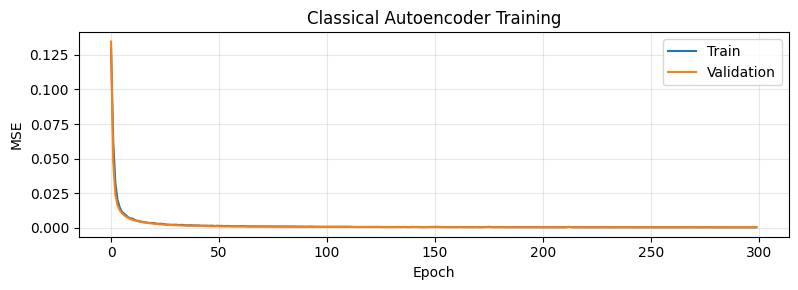

In [6]:
# Training loop with Train/Val monitoring
import matplotlib.pyplot as plt

epochs       = 300
train_losses = []
val_losses   = []

for epoch in range(epochs):
    autoencoder.train()
    epoch_loss = 0.0
    for (batch,) in train_loader:
        out  = autoencoder(batch)
        loss = criterion(out, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(train_tensor))

    autoencoder.eval()
    with torch.no_grad():
        val_out  = autoencoder(val_tensor)
        val_loss = criterion(val_out, val_tensor).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs}  train={train_losses[-1]:.6f}  val={val_loss:.6f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Classical Autoencoder Training')
plt.tight_layout(); plt.show()


In [7]:
# PCA auf Latent Space (20D → 10D)
final_latent_dim = 10  # = Anzahl Qubits

autoencoder.eval()
with torch.no_grad():
    latent_train = autoencoder.encoder(train_tensor).numpy()
    latent_val   = autoencoder.encoder(val_tensor).numpy()
    latent_mal   = autoencoder.encoder(
        torch.tensor(X_malicious_scaled, dtype=torch.float32)
    ).numpy()

# PCA nur auf Train fitten
pca_on_latent = PCA(n_components=final_latent_dim)
Z_train = pca_on_latent.fit_transform(latent_train)
Z_val   = pca_on_latent.transform(latent_val)
Z_mal   = pca_on_latent.transform(latent_mal)

explained = pca_on_latent.explained_variance_ratio_
print(f'Explained variance (10 PCs): {explained.sum():.4f}')
print(f'Per component: {np.round(explained, 4)}')


Explained variance (10 PCs): 0.9672
Per component: [0.4467 0.2589 0.0917 0.0433 0.0297 0.0263 0.0224 0.0203 0.0154 0.0125]


In [8]:
# Falls noch nicht vorhanden:
# pip install qiskit qiskit-aer matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity, partial_trace
from qiskit.primitives import StatevectorSampler

from scipy.optimize import minimize

np.random.seed(42)

In [9]:
# Angle Encoding Setup
# FEATURE_RANGES aus Z_train (PCA-Output, nur Benign-Train)
FEATURE_RANGES = np.array([Z_train.min(axis=0), Z_train.max(axis=0)]).T

def normalize_features(features, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Min-max Skalierung auf [0, angle_max]."""
    features = np.asarray(features, dtype=float)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    norm = (features - fmin) / (fmax - fmin + 1e-12)
    return np.clip(norm, 0.0, 1.0) * angle_max

def denormalize_features(angles, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Inverse: Winkel → PCA-Koeffizienten."""
    angles = np.where(angles < 0.0, angles + 2.0 * np.pi, angles)
    norm   = np.clip(angles / angle_max, 0.0, 1.0)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    return norm * (fmax - fmin) + fmin

def angle_encode(angles, rotation="ry"):
    """Ein Feature pro Qubit, single-qubit Rotation."""
    n  = len(angles)
    qc = QuantumCircuit(n, name="AngleEncoding")
    for i, theta in enumerate(angles):
        if rotation == "ry":
            qc.ry(theta, i)
        elif rotation == "rx":
            qc.rx(theta, i)
        elif rotation == "rz":
            qc.h(i)
            qc.rz(theta, i)
        else:
            raise ValueError(f"unsupported rotation: {rotation}")
    return qc

# Normalisieren + State-Preparation-Schaltkreise bauen (nur Benign-Train)
training_angles = np.stack([normalize_features(z) for z in Z_train])
training_states = [angle_encode(a, rotation="ry") for a in training_angles]

print(f"Winkel-Range über alle Flows: [{training_angles.min():.3f}, {training_angles.max():.3f}] rad")
print(f"Trainingszustände: {len(training_states)} × {training_states[0].num_qubits} Qubits")


Winkel-Range über alle Flows: [0.000, 3.142] rad
Trainingszustände: 1306 × 10 Qubits


In [10]:
num_latent  = 4
num_trash   = 6
num_qubits  = num_latent + num_trash       # 10  (Eingang = #features)
ansatz_reps = 5

total_qubits = num_latent + 2 * num_trash + 1  # 17
aux_qubit    = num_latent + 2 * num_trash      # Index des Auxiliary-Qubits

print(f"Eingangs-Qubits (Features):      {num_qubits}")
print(f"Latent-Qubits:                   {num_latent}")
print(f"Trash-Qubits:                    {num_trash}")
print(f"Total Qubits (mit SWAP-Test):    {total_qubits}")


Eingangs-Qubits (Features):      10
Latent-Qubits:                   4
Trash-Qubits:                    6
Total Qubits (mit SWAP-Test):    17


/var/folders/20/lcst4q7d7292grcdmdn50f_w0000gn/T/ipykernel_17526/2474737763.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=ansatz_reps)


Anzahl trainierbarer Parameter: 60


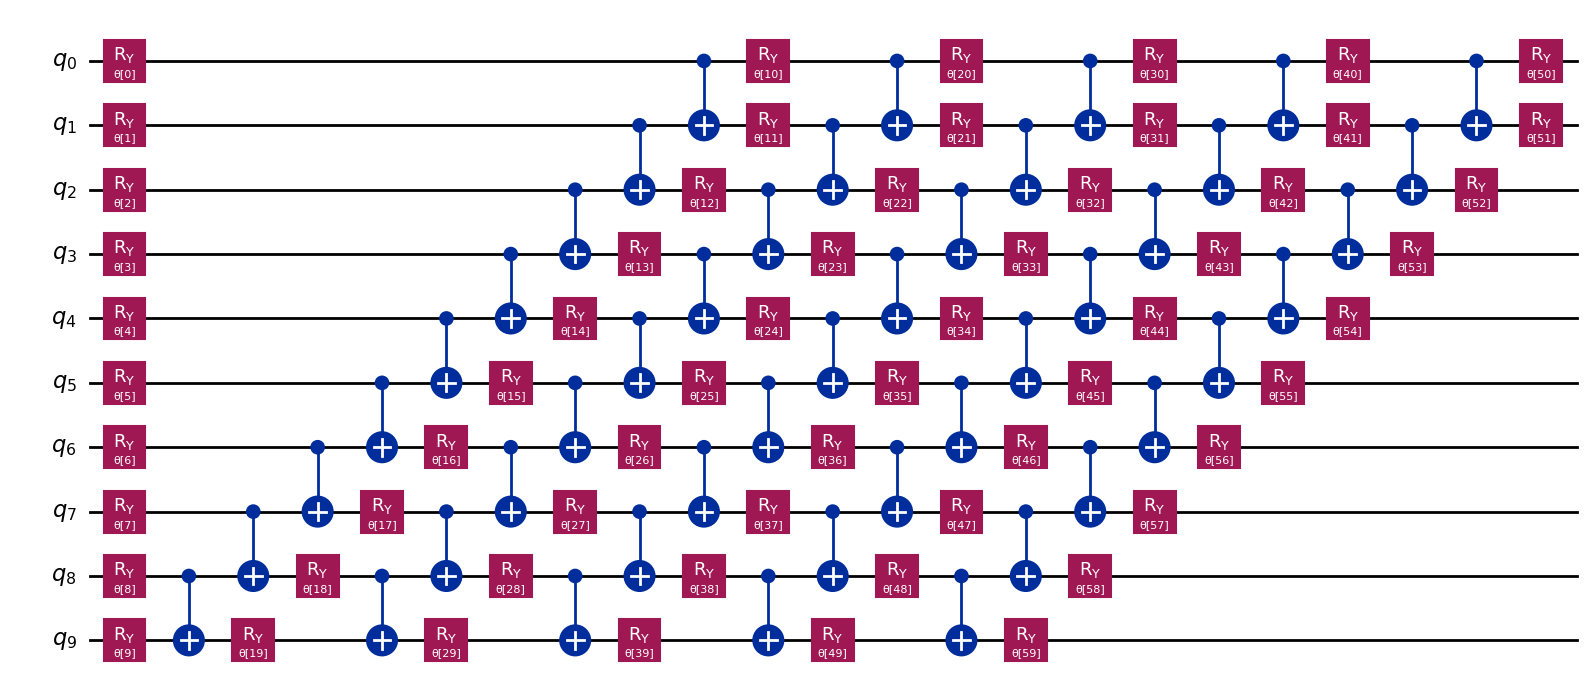

In [11]:
ansatz = RealAmplitudes(num_qubits, reps=ansatz_reps)
print(f"Anzahl trainierbarer Parameter: {ansatz.num_parameters}")
ansatz.decompose().draw("mpl", fold=-1)


Total Qubits:  17
Parameter:     60


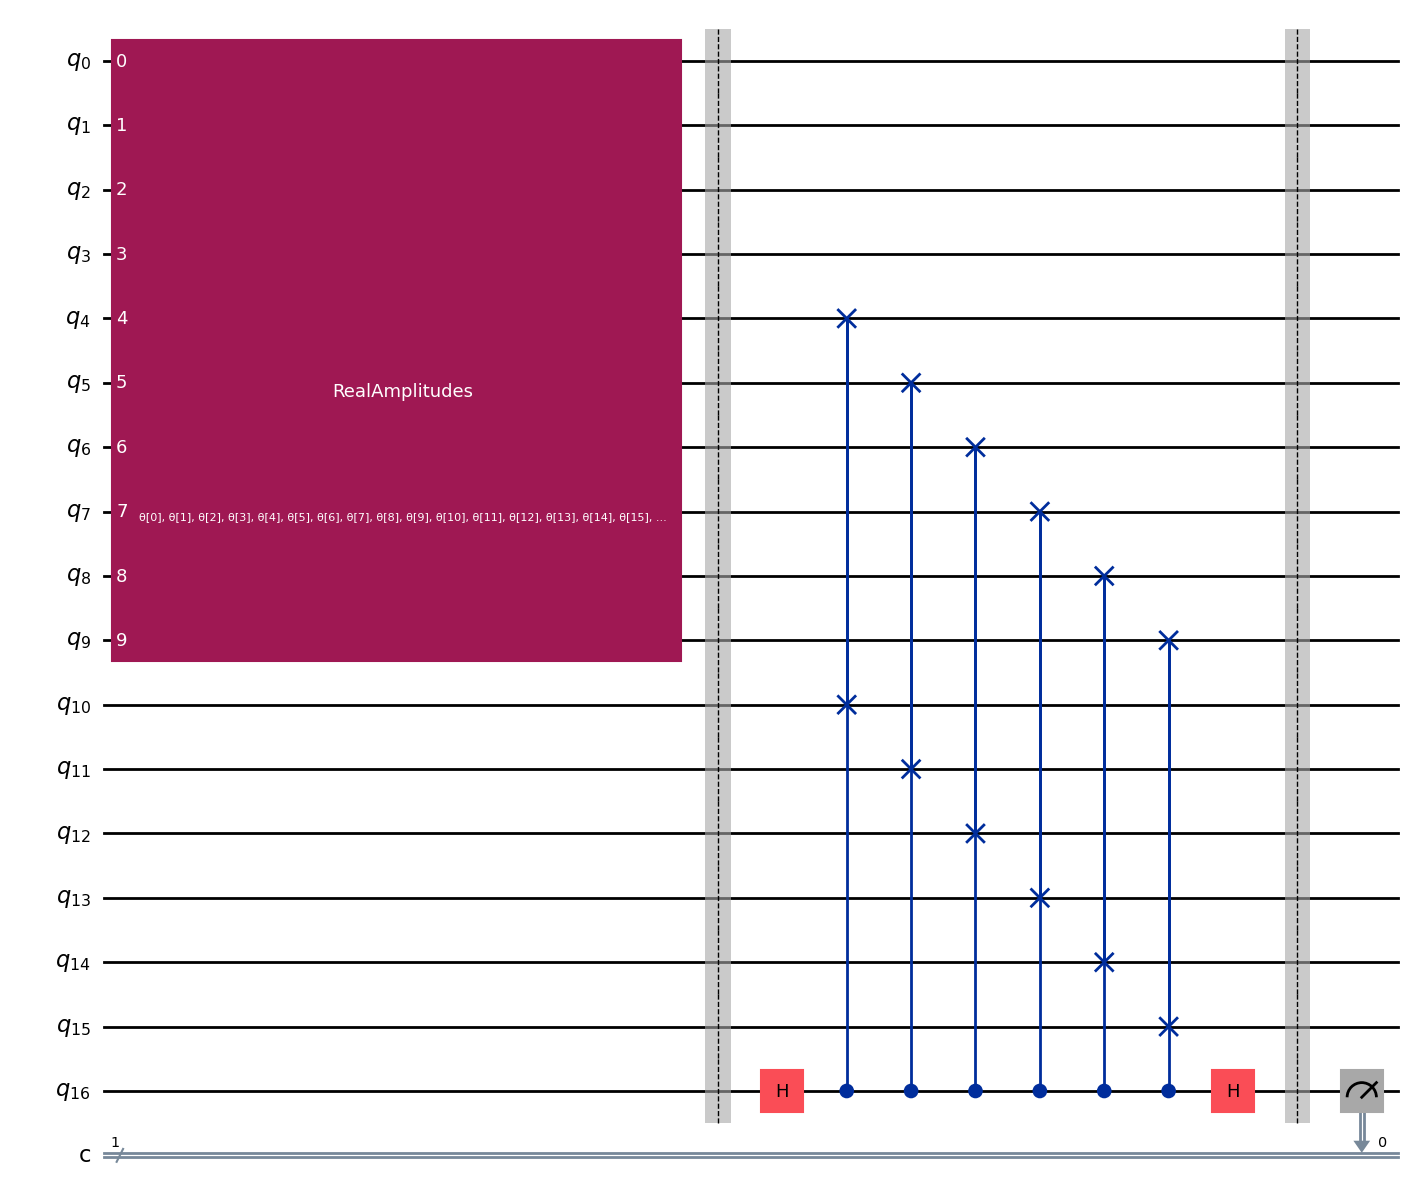

In [12]:
def auto_encoder_circuit(num_latent, num_trash, ansatz):
    """Encoder + SWAP-Test (Trash ↔ Referenzregister)."""
    from qiskit import QuantumRegister, ClassicalRegister
    total = num_latent + 2 * num_trash + 1
    aux   = num_latent + 2 * num_trash

    qr = QuantumRegister(total, "q")
    cr = ClassicalRegister(1, "c")
    qc = QuantumCircuit(qr, cr)

    qc.compose(ansatz, qubits=range(num_latent + num_trash), inplace=True)
    qc.barrier()

    qc.h(aux)
    for i in range(num_trash):
        qc.cswap(aux, num_latent + i, num_latent + num_trash + i)
    qc.h(aux)
    qc.barrier()

    qc.measure(aux, cr[0])
    return qc


ae_circuit = auto_encoder_circuit(num_latent, num_trash, ansatz)
print(f"Total Qubits:  {ae_circuit.num_qubits}")
print(f"Parameter:     {ae_circuit.num_parameters}")
ae_circuit.draw("mpl", fold=-1)


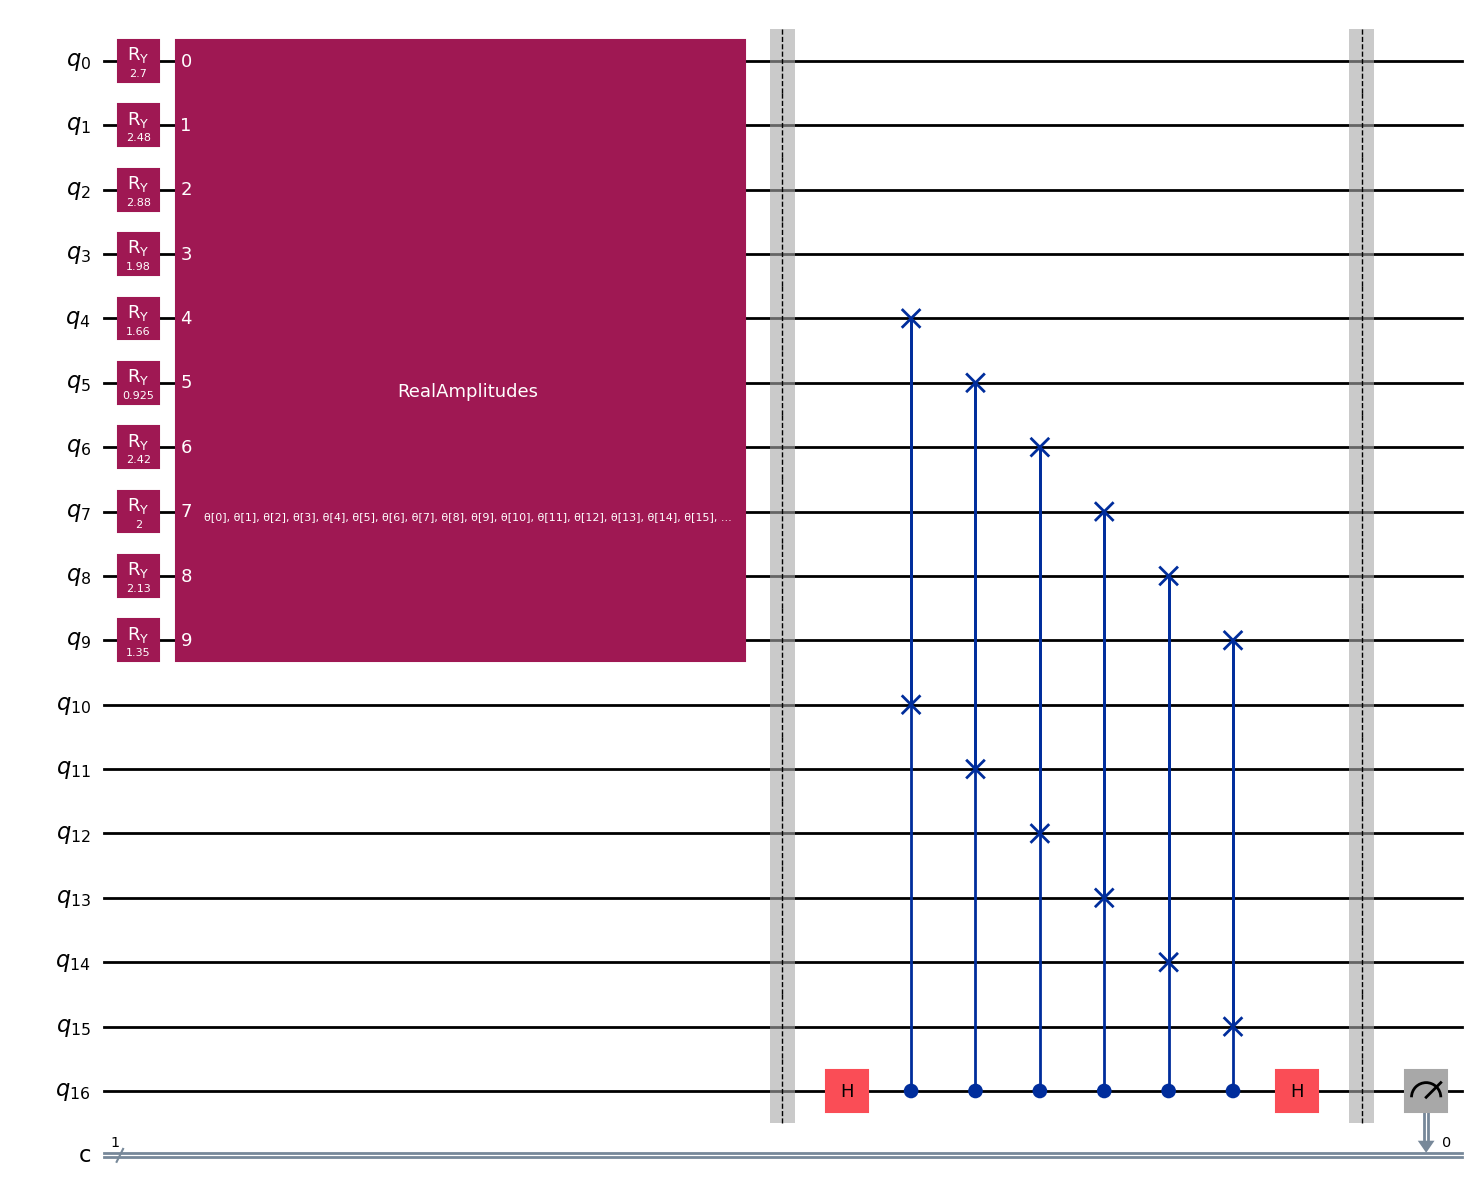

In [13]:
def build_full_circuit(state_prep, ae_circuit):
    """State-Prep + Autoencoder-Trainings-Schaltkreis."""
    full = QuantumCircuit(*ae_circuit.qregs, *ae_circuit.cregs)
    full.compose(state_prep, qubits=range(state_prep.num_qubits), inplace=True)
    full.compose(ae_circuit, inplace=True)
    return full


training_circuits = [build_full_circuit(sp, ae_circuit) for sp in training_states]

sampler = StatevectorSampler()
SHOTS = 1024

cost_history = []

def cost_function(params):
    """Mittel von P(|1⟩_aux) über alle Trainings-Flows."""
    param_dict = dict(zip(ansatz.parameters, params))
    bound = [qc.assign_parameters(param_dict) for qc in training_circuits]

    job    = sampler.run(bound, shots=SHOTS)
    result = job.result()

    cost = 0.0
    for pub_result in result:
        counts = pub_result.data.c.get_counts()
        total  = sum(counts.values())
        cost  += counts.get("1", 0) / total
    cost /= len(training_circuits)

    cost_history.append(cost)
    if len(cost_history) % 10 == 0:
        print(f"Iter {len(cost_history):4d}   cost = {cost:.4f}")
    return cost

## just clip to first 10 circuits for testing
training_circuits = training_circuits[:10]

training_circuits[0].draw("mpl")


In [30]:
import os

if os.path.exists("trained_params.npy"):
    initial_params = np.load("trained_params.npy")
    print("Gespeicherte Parameter geladen.")
else:
    initial_params = np.random.uniform(-0.1, 0.1, ansatz.num_parameters)
    print("Neue Zufallsparameter initialisiert.")
    
print(f"Starte Training mit {ansatz.num_parameters} Parametern, {len(training_circuits)} Trainings-Flows...")
print(f"Initiale Kosten: {cost_function(initial_params):.4f}\n")

result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 200, "rhobeg": 0.5, "disp": True},
)

optimal_params = result.x

np.save("trained_params.npy", optimal_params)
print("Parameter gespeichert.")

print(f"\nFinale Kosten:                {result.fun:.4f}")
print(f"Implizite mittlere Fidelität: {1 - 2*result.fun:.4f}")
print(f"Anzahl Funktionsauswertungen: {result.nfev}")


Gespeicherte Parameter geladen.
Starte Training mit 60 Parametern, 10 Trainings-Flows...
Initiale Kosten: 0.1897

Iter  410   cost = 0.2185
Iter  420   cost = 0.2045
Iter  430   cost = 0.2037
Iter  440   cost = 0.2108
Iter  450   cost = 0.2150
Iter  460   cost = 0.2007
Iter  470   cost = 0.1832
Iter  480   cost = 0.1805
Iter  490   cost = 0.1829
Iter  500   cost = 0.1790
Iter  510   cost = 0.1855
Iter  520   cost = 0.1913
Iter  530   cost = 0.1780
Iter  540   cost = 0.1795
Iter  550   cost = 0.1833
Iter  560   cost = 0.1856
Iter  570   cost = 0.1795
Iter  580   cost = 0.1879
Iter  590   cost = 0.1862
Iter  600   cost = 0.1805
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 200   Least value of F = 0.1748046875
The corresponding X is:
[ 4.56153577e-01 -2.07822575e+00 -7.26888326e-01 -6.48710098e-01
  7.18200594e-01 -4.40967750e-01 -6.61134098e-01 -7.95929911e-02
 -1.36326528e-01  3.41901026e-01  4.35118798e-01  1.84707777e-0

In [15]:
np.save("trained_params.npy", optimal_params)
print("Parameter gespeichert.")

Parameter gespeichert.


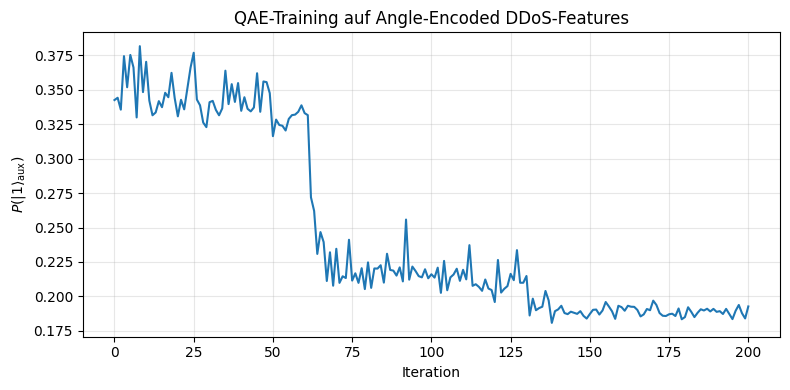

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel(r"$P(|1\rangle_{\mathrm{aux}})$")
plt.title("QAE-Training auf Angle-Encoded DDoS-Features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def reconstruct(state_prep, encoder_params):
    """Encode + Reset Trash + Decode → 10-Qubit-Schaltkreis (gemischter Zustand)."""
    encoder = ansatz.assign_parameters(
        dict(zip(ansatz.parameters, encoder_params))
    )
    decoder = encoder.inverse()

    qc = QuantumCircuit(num_qubits)
    qc.compose(state_prep, inplace=True)
    qc.compose(encoder, inplace=True)

    for i in range(num_latent, num_qubits):
        qc.reset(i)

    qc.compose(decoder, inplace=True)
    return qc

# also clip training states for testing
training_states = training_states[:10]


fidelities = []
for sp in training_states:
    qc      = reconstruct(sp, optimal_params)
    rho_out = DensityMatrix(qc)
    psi_in  = Statevector(sp)
    fidelities.append(state_fidelity(rho_out, psi_in))
    print(f"Fidelity: {fidelities[-1]:.4f}")

fidelities = np.array(fidelities)
print(f"Mittlere Fidelität: {fidelities.mean():.4f}")
print(f"Min:               {fidelities.min():.4f}")


Fidelity: 0.7201
Fidelity: 0.7201
Fidelity: 0.7019
Fidelity: 0.3407
Fidelity: 0.0786
Fidelity: 0.5557
Fidelity: 0.7297
Fidelity: 0.3710
Fidelity: 0.7201
Fidelity: 0.1724
Mittlere Fidelität: 0.5110
Min:               0.0786


In [18]:
_X = np.array([[0, 1], [1, 0]], dtype=complex)
_Z = np.array([[1, 0], [0, -1]], dtype=complex)

def angle_decode_density(rho, num_qubits, rotation="ry"):
    """Winkel-Decoding aus reduzierten 1-Qubit-Dichtematrizen."""
    angles = np.zeros(num_qubits)
    for i in range(num_qubits):
        rho_i = partial_trace(rho, [j for j in range(num_qubits) if j != i]).data
        ex    = float(np.real(np.trace(rho_i @ _X)))
        ez    = float(np.real(np.trace(rho_i @ _Z)))
        if rotation == "ry":
            angles[i] = np.arctan2(ex, ez)
        else:
            raise NotImplementedError("nur ry hier")
    return angles

# Beispiel-Rekonstruktion auf einem Trainings-Sample (zum Debuggen)
example_state = training_states[0]
qc_recon      = reconstruct(example_state, optimal_params)
rho_out       = DensityMatrix(qc_recon)

angles_in    = training_angles[0]
angles_recon = angle_decode_density(rho_out, num_qubits, rotation="ry")

raw_in    = Z_train[0]                        # PCA-Raum (10D)
raw_recon = denormalize_features(angles_recon)

print(f"Differenz angles_in vs angles_recon: {angles_in - angles_recon}")
print(f"Differenz Z_train[0] vs raw_recon:   {raw_in - raw_recon}")


Differenz angles_in vs angles_recon: [-0.00479787  0.29483028  0.09522905 -0.16982461  0.13002086  0.00907747
  0.05184558 -0.07007075  0.37203383 -0.00800256]
Differenz Z_train[0] vs raw_recon:   [-0.00610923  0.3170088   0.09072946 -0.18923394  0.11336321  0.00585472
  0.02974104 -0.05328657  0.29276371 -0.00450368]


In [19]:
# Decode: Z_train (10D PCA) → AE Latent (20D) → Original Feature Space
latent_from_pca = pca_on_latent.inverse_transform(Z_train)        # (N_train, 20)
latent_tensor   = torch.tensor(latent_from_pca, dtype=torch.float32)
with torch.no_grad():
    reconstructed_scaled = autoencoder.decoder(latent_tensor).numpy()  # (N_train, input_dim)

X_reconstructed = scaler_01.inverse_transform(reconstructed_scaled)
df_reconstructed = pd.DataFrame(X_reconstructed, columns=feature_names)
display(df_reconstructed.head())


,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,pps_max,bps_mean,bps_max,duration_mean,duration_max,packet_size_avg_mean,...,total_packets_sum,total_bytes_sum,dst_concentration,dst_port_concentration,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share
0,1.123230,1.033740,1.002381,1015.691406,870.325806,91174.359375,1.117708e+05,0.017055,0.069181,98.461647,...,16.274912,5.746975e+03,0.998379,0.989339,0.001014,0.996237,0.000010,0.998403,0.000069,0.993606
1,1.123232,1.033741,1.002381,1015.696716,870.334595,91174.359375,1.117713e+05,0.017055,0.069180,98.461479,...,16.275057,5.747083e+03,0.998379,0.989339,0.001014,0.996237,0.000010,0.998402,0.000069,0.993606
2,9.987828,2962.157959,1.999176,2787.859131,14819.317383,525376.062500,4.318117e+06,0.260795,43.635685,221.125015,...,807396.812500,3.835645e+08,0.106265,0.219058,0.766953,0.231315,0.001298,0.617125,0.060440,0.053381
3,2.202929,1.213330,1.942241,66.145943,368.107239,6039.980469,4.988818e+04,115.982445,120.351753,67.199966,...,221.132797,1.947354e+05,0.966442,0.996474,0.002626,0.011063,0.021198,0.999201,0.000129,0.999793
4,8.003242,6.819056,1.380187,540.675171,3257.175781,201875.906250,1.301084e+06,1.422390,8.903681,279.139587,...,1486.525635,8.371983e+05,0.268455,0.125882,0.954167,0.046426,0.002431,0.607274,0.005910,0.385217


In [20]:
# Rekonstruktionsfehler pro Sample und Feature (Trainings-Daten)
diff = reconstructed_scaled - X_train_scaled  # beide im [0,1] skalierten Raum

mse_per_sample  = np.mean(diff**2, axis=1)
mse_per_feature = np.mean(diff**2, axis=0)
mae_per_sample  = np.mean(np.abs(diff), axis=1)
overall_mse     = np.mean(diff**2)

print(f"Gesamt MSE: {overall_mse:.6f}")
print(f"Gesamt MAE: {np.mean(np.abs(diff)):.6f}")


Gesamt MSE: 0.001384
Gesamt MAE: 0.017408


In [21]:
# Fehler im Original-Raum
X_reconstructed_orig = scaler_01.inverse_transform(reconstructed_scaled)
X_original_orig      = X_train  # unscaled Trainings-Daten

diff_orig            = X_reconstructed_orig - X_original_orig
mse_per_feature_orig = np.mean(diff_orig**2, axis=0)
feature_errors       = pd.Series(mse_per_feature_orig, index=feature_names).sort_values(ascending=False)
print(feature_errors)


total_bytes_sum            5.298430e+13
bps_max                    1.353470e+11
bps_mean                   4.577820e+09
total_packets_sum          1.364127e+08
pps_max                    6.448622e+05
pps_mean                   1.088455e+04
unique_dst_port            1.922280e+03
packet_size_avg_mean       1.469120e+03
packet_size_avg_std        1.174201e+03
inter_arrival_std_mean     7.004844e+01
duration_max               3.626409e+01
inter_arrival_mean_mean    1.663126e+01
duration_mean              8.070855e+00
unique_dst_ip              1.270417e-01
unique_protocols           3.303945e-02
dst_port_concentration     1.755913e-03
low_outbound_share         1.253047e-03
dst_concentration          1.109451e-03
udp_share                  9.732175e-04
tcp_share                  8.009712e-04
small_packet_share         7.938056e-04
outbound_ratio_mean        6.181983e-04
high_pps_share             1.753635e-04
outbound_ratio_min         1.141079e-04
icmp_share                 8.514486e-05


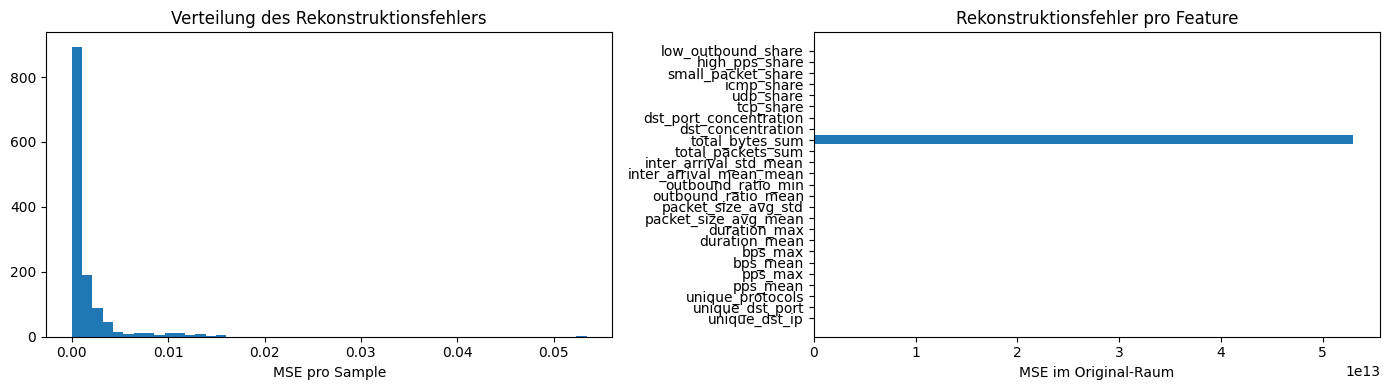

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MSE pro Sample — Ausreißer sichtbar machen
axes[0].hist(mse_per_sample, bins=50)
axes[0].set_xlabel("MSE pro Sample")
axes[0].set_title("Verteilung des Rekonstruktionsfehlers")

# Fehler pro Feature
axes[1].barh(feature_names, mse_per_feature_orig)
axes[1].set_xlabel("MSE im Original-Raum")
axes[1].set_title("Rekonstruktionsfehler pro Feature")

plt.tight_layout()
plt.show()


## Klassische Pipeline Validierung

End-to-end Rekonstruktion: Original → AE-Encode → PCA → PCA-inv → AE-Decode. 
Dieser Fehler dient als Baseline und direkt als Anomalie-Score für DDoS-Detektion.


Classical Pipeline MSE (train benign): 0.001384 ± 0.002835
Classical Pipeline MSE (val benign):   0.001670 ± 0.002897
Classical Pipeline MSE (malicious):    0.097313 ± 0.249463


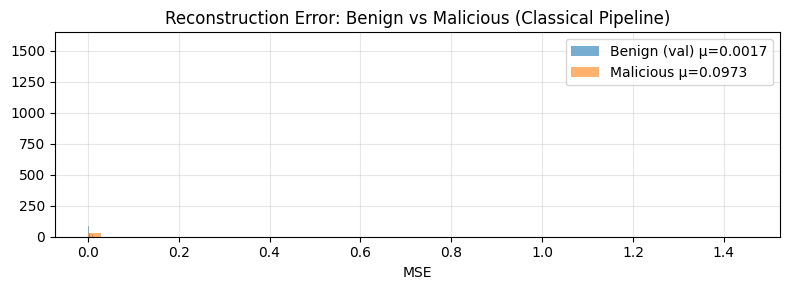

In [23]:
# ===== KLASSISCHE PIPELINE VALIDIERUNG =====
def classical_reconstruct(X_scaled, autoencoder, pca):
    """Volle klassische Rekonstruktion inkl. PCA-Verlust."""
    autoencoder.eval()
    with torch.no_grad():
        latent = autoencoder.encoder(torch.tensor(X_scaled, dtype=torch.float32)).numpy()
        z      = pca.transform(latent)
        latent_recon = pca.inverse_transform(z)
        recon  = autoencoder.decoder(torch.tensor(latent_recon, dtype=torch.float32)).numpy()
    return recon

recon_train = classical_reconstruct(X_train_scaled, autoencoder, pca_on_latent)
recon_val   = classical_reconstruct(X_val_scaled,   autoencoder, pca_on_latent)
recon_mal   = classical_reconstruct(X_malicious_scaled, autoencoder, pca_on_latent)

mse_train = np.mean((recon_train - X_train_scaled)**2, axis=1)
mse_val   = np.mean((recon_val   - X_val_scaled)**2,   axis=1)
mse_mal   = np.mean((recon_mal   - X_malicious_scaled)**2, axis=1)

print(f'Classical Pipeline MSE (train benign): {mse_train.mean():.6f} ± {mse_train.std():.6f}')
print(f'Classical Pipeline MSE (val benign):   {mse_val.mean():.6f} ± {mse_val.std():.6f}')
print(f'Classical Pipeline MSE (malicious):    {mse_mal.mean():.6f} ± {mse_mal.std():.6f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(mse_val, bins=50, alpha=0.6, label=f'Benign (val) μ={mse_val.mean():.4f}', density=True)
ax.hist(mse_mal, bins=50, alpha=0.6, label=f'Malicious μ={mse_mal.mean():.4f}', density=True)
ax.set_xlabel('MSE'); ax.legend()
ax.set_title('Reconstruction Error: Benign vs Malicious (Classical Pipeline)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## DDoS-Detektion via Rekonstruktionsfehler (Klassische Pipeline)


In [24]:
# ===== DDOS DETEKTION — Klassische Pipeline =====

# Score: MSE-Rekonstruktionsfehler
score_val = mse_val   # benign validation
score_mal = mse_mal   # malicious

y_true  = np.concatenate([np.zeros(len(score_val)), np.ones(len(score_mal))])
y_score = np.concatenate([score_val, score_mal])

# ROC + AUC
auc            = roc_auc_score(y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# Optimaler Threshold (Youden's J)
j_scores       = tpr - fpr
best_idx       = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

y_pred = (y_score >= best_threshold).astype(int)
f1     = f1_score(y_true, y_pred)

print(f'=== DDoS Detection Results (Classical Pipeline) ===')
print(f'AUC-ROC:          {auc:.4f}')
print(f'Best Threshold:   {best_threshold:.6f}')
print(f'F1-Score:         {f1:.4f}')
print(f'TPR @ threshold:  {tpr[best_idx]:.4f}')
print(f'FPR @ threshold:  {fpr[best_idx]:.4f}')


=== DDoS Detection Results (Classical Pipeline) ===
AUC-ROC:          0.9146
Best Threshold:   0.002636
F1-Score:         0.9142
TPR @ threshold:  0.8921
FPR @ threshold:  0.1743


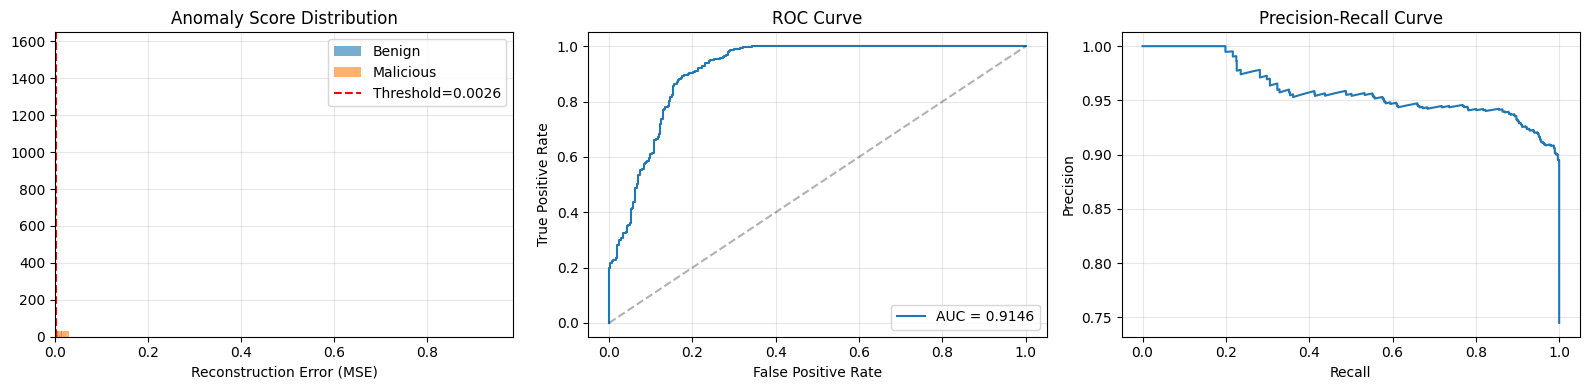

In [25]:
# ===== VISUALISIERUNG — DDoS Detection =====
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Score-Verteilung
axes[0].set_xlim(0, np.percentile(np.concatenate([score_val, score_mal]), 99))
axes[0].hist(score_val, bins=50, alpha=0.6, label='Benign', density=True)
axes[0].hist(score_mal, bins=50, alpha=0.6, label='Malicious', density=True)
axes[0].axvline(best_threshold, color='r', ls='--', label=f'Threshold={best_threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_title('Anomaly Score Distribution')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. ROC Curve
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_score)
axes[2].plot(recall, precision)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Quantum Fidelity: Benign vs. Malicious

Der QAE arbeitet im 10-Qubit-Hilbertraum. Wir prüfen hier, ob die State Fidelity 
nach QAE-Encode → Reset-Trash → Decode zwischen Benign und Malicious unterscheidet.


In [26]:
# ===== QAE ANGLE ENCODING (Benign + Malicious) =====
FEATURE_RANGES = np.array([Z_train.min(axis=0), Z_train.max(axis=0)]).T

def normalize_to_angles(features, ranges=FEATURE_RANGES, angle_max=np.pi):
    features = np.asarray(features, dtype=float)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    norm = (features - fmin) / (fmax - fmin + 1e-12)
    return np.clip(norm, 0.0, 1.0) * angle_max

def angles_to_features(angles, ranges=FEATURE_RANGES, angle_max=np.pi):
    angles = np.where(angles < 0.0, angles + 2.0 * np.pi, angles)
    norm   = np.clip(angles / angle_max, 0.0, 1.0)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    return norm * (fmax - fmin) + fmin

def make_angle_circuit(angles):
    n  = len(angles)
    qc = QuantumCircuit(n, name='AngleEnc')
    for i, theta in enumerate(angles):
        qc.ry(float(theta), i)
    return qc

val_angles = np.array([normalize_to_angles(z) for z in Z_val])
mal_angles = np.array([normalize_to_angles(z) for z in Z_mal])

print(f'Val  angles shape: {val_angles.shape}')
print(f'Mal  angles shape: {mal_angles.shape}')


Val  angles shape: (327, 10)
Mal  angles shape: (955, 10)


QAE Fidelity (Benign):    0.4175 ± 0.2479
QAE Fidelity (Malicious): 0.1415 ± 0.0588


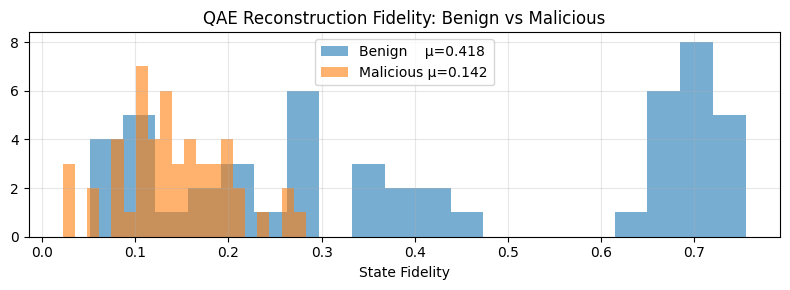

In [ ]:
# ===== QAE FIDELITY VERGLEICH: Benign vs. Malicious =====
from qiskit.quantum_info import DensityMatrix, state_fidelity, partial_trace, Statevector

def compute_fidelity(state_prep, params):
    """Fidelity zwischen Input und rekonstruiertem Zustand (via vorhandenem reconstruct())."""
    qc      = reconstruct(state_prep, params)
    rho_out = DensityMatrix(qc)
    psi_in  = Statevector(state_prep)
    return state_fidelity(rho_out, psi_in)

rng        = np.random.default_rng(42)
N_COMPARE  = min(15, len(val_angles), len(mal_angles))

fid_benign    = []
fid_malicious = []

for i in range(N_COMPARE):
    sp_b = make_angle_circuit(val_angles[i])
    fid_benign.append(compute_fidelity(sp_b, optimal_params))

    sp_m = make_angle_circuit(mal_angles[i])
    fid_malicious.append(compute_fidelity(sp_m, optimal_params))

fid_benign    = np.array(fid_benign)
fid_malicious = np.array(fid_malicious)

print(f'QAE Fidelity (Benign):    {fid_benign.mean():.4f} ± {fid_benign.std():.4f}')
print(f'QAE Fidelity (Malicious): {fid_malicious.mean():.4f} ± {fid_malicious.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(fid_benign,    bins=20, alpha=0.6, label=f'Benign    μ={fid_benign.mean():.3f}')
ax.hist(fid_malicious, bins=20, alpha=0.6, label=f'Malicious μ={fid_malicious.mean():.3f}')
ax.set_xlabel('State Fidelity')
ax.set_title('QAE Reconstruction Fidelity: Benign vs Malicious')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Full Pipeline Reconstruction Error: Benign vs. Malicious


In [28]:
# ===== FULL PIPELINE: Benign vs. Malicious Reconstruction Error =====
_X_op = np.array([[0, 1], [1, 0]], dtype=complex)
_Z_op = np.array([[1, 0], [0, -1]], dtype=complex)

def decode_angles_from_sv(qc, nq):
    rho    = DensityMatrix(qc)
    angles = np.zeros(nq)
    for i in range(nq):
        trace_out = [j for j in range(nq) if j != i]
        rho_i     = partial_trace(rho, trace_out).data
        ex        = float(np.real(np.trace(rho_i @ _X_op)))
        ez        = float(np.real(np.trace(rho_i @ _Z_op)))
        angles[i] = np.arctan2(ex, ez)
    return angles

def full_pipeline_reconstruct(angles_10d, optimal_params, pca, autoencoder, scaler):
    sp       = make_angle_circuit(angles_10d)
    qc_recon = reconstruct(sp, optimal_params)
    angles_recon  = decode_angles_from_sv(qc_recon, num_qubits)
    z_recon       = angles_to_features(angles_recon)
    latent_recon  = pca.inverse_transform(z_recon.reshape(1, -1))
    autoencoder.eval()
    with torch.no_grad():
        x_recon_scaled = autoencoder.decoder(
            torch.tensor(latent_recon, dtype=torch.float32)
        ).numpy()
    return x_recon_scaled.flatten()

N_COMPARE    = min(20, len(val_angles), len(mal_angles))
val_indices  = rng.choice(len(val_angles), N_COMPARE, replace=False)
mal_indices  = rng.choice(len(mal_angles), N_COMPARE, replace=False)

recon_errors_benign    = []
recon_errors_malicious = []

for idx in val_indices:
    r    = full_pipeline_reconstruct(val_angles[idx], optimal_params, pca_on_latent, autoencoder, scaler_01)
    orig = X_val_scaled[idx]
    recon_errors_benign.append(np.mean((r - orig)**2))

for idx in mal_indices:
    r    = full_pipeline_reconstruct(mal_angles[idx], optimal_params, pca_on_latent, autoencoder, scaler_01)
    orig = X_malicious_scaled[idx]
    recon_errors_malicious.append(np.mean((r - orig)**2))

recon_errors_benign    = np.array(recon_errors_benign)
recon_errors_malicious = np.array(recon_errors_malicious)

print(f'Full Pipeline Reconstruction Error:')
print(f'  Benign:    {recon_errors_benign.mean():.4f} ± {recon_errors_benign.std():.4f}')
print(f'  Malicious: {recon_errors_malicious.mean():.4f} ± {recon_errors_malicious.std():.4f}')

# ROC aus Full-Pipeline-Scores
y_true_fp  = np.concatenate([np.zeros(N_COMPARE), np.ones(N_COMPARE)])
y_score_fp = np.concatenate([recon_errors_benign, recon_errors_malicious])
auc_fp     = roc_auc_score(y_true_fp, y_score_fp)
fpr_fp, tpr_fp, _ = roc_curve(y_true_fp, y_score_fp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(recon_errors_benign,    bins=15, alpha=0.6,
             label=f'Benign    μ={recon_errors_benign.mean():.3f}', density=True)
axes[0].hist(recon_errors_malicious, bins=15, alpha=0.6,
             label=f'Malicious μ={recon_errors_malicious.mean():.3f}', density=True)
axes[0].set_xlabel('Reconstruction MSE (scaled space)')
axes[0].set_ylabel('Density')
axes[0].set_title('Full Quantum Pipeline:\nBenign vs. Malicious')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(fpr_fp, tpr_fp, label=f'Full Pipeline AUC = {auc_fp:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Full Quantum Pipeline)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


KeyboardInterrupt: 

## Zusammenfassung

| Stufe | Methode | Dimensionen | Verlust |
|-------|---------|-------------|---------|
| 1. Classical AE | Nonlinear (PyTorch, BatchNorm) | N_features → 20 | MSE train vs val |
| 2. PCA | Linear | 20 → 10 | Explained variance |
| 3. Quantum AE | Parameterized circuit (RealAmplitudes) | 10 → 4 latent | SWAP-Test / Fidelity |
| **Gesamt** | | N_features → 4 Qubits | End-to-end MSE + Fidelity |

**DDoS-Detektion:** Rekonstruktionsfehler als Anomalie-Score mit ROC/AUC/F1 Evaluation — 
identische Metrik wie im `ddos_qae_validated_v3`-Notebook für direkte Vergleichbarkeit.
